In [1]:
 import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:

df = pd.read_csv("patient_segmentation_dataset.csv")
print(df.head())

  PatientID  Age  Gender State     City  Height_cm  Weight_kg   BMI  \
0    P10000   64    Male    GA  Unknown        151        115  50.4   
1    P10001   59    Male    OH  Unknown        189         68  19.0   
2    P10002   58  Female    PA  Unknown        156         91  37.4   
3    P10003   43  Female    GA  Unknown        152         92  39.8   
4    P10004   53  Female    NC  Unknown        167         51  18.3   

  Insurance_Type Primary_Condition  Num_Chronic_Conditions  Annual_Visits  \
0        Private         Arthritis                       3              7   
1       Medicare        Depression                       1              8   
2        Private            Asthma                       1              4   
3       Medicare      Hypertension                       1              6   
4       Medicaid            Asthma                       1              4   

   Avg_Billing_Amount Last_Visit_Date  Days_Since_Last_Visit  \
0              2995.0      2025-07-18         

In [3]:

X = df[[
    "Age",
    "BMI"
]]
X

,Age,BMI
0,64,50.4
1,59,19.0
2,58,37.4
3,43,39.8
4,53,18.3
...,...,...
1995,37,28.7
1996,32,41.2
1997,50,51.8
1998,74,35.6


In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [6]:
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters


In [7]:
df["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)
    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Age",
                "BMI"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


CLUSTER 1
      Age   BMI
2      58  37.4
3      43  39.8
4      53  18.3
10     47  20.8
12     43  25.8
...   ...   ...
1988   50  28.6
1992   41  44.4
1993   54  14.6
1997   50  51.8
1999   57  31.5

[807 rows x 2 columns]

Total Records : 807

CLUSTER 2
      Age   BMI
0      64  50.4
1      59  19.0
5      73  46.9
7      64  32.6
8      61  29.4
...   ...   ...
1986   65  45.6
1989   65  36.0
1991   64  38.3
1994   78  39.5
1998   74  35.6

[666 rows x 2 columns]

Total Records : 666

CLUSTER 3
      Age   BMI
6      34  19.7
9      34  33.5
19     32  29.9
21     19  20.5
22     41  21.9
...   ...   ...
1979   32  26.1
1985   24  39.5
1990   33  26.8
1995   37  28.7
1996   32  41.2

[527 rows x 2 columns]

Total Records : 527


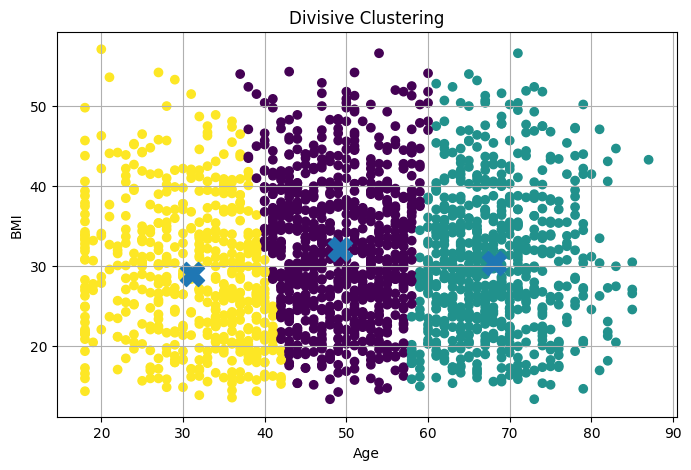

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    X["Age"],
    X["BMI"],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Age")
plt.ylabel("BMI")

plt.title("Divisive Clustering")

plt.grid(True)

plt.show()

